<a href="https://colab.research.google.com/github/HeberBernal/Olist-Logistics-Machine-Learning-and-Prescription/blob/main/Modelado_Predictivo_Brazilian_E_Commerce_Public_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Olist Logistics - Fase 2: Machine Learning y Analítica Prescriptiva**

In [7]:
import pandas as pd
import os

# 1. FUNCIÓN DE CARGA INTELIGENTE (La misma que usamos en la Fase 1)
def find_and_load(pattern):
    for root, dirs, files in os.walk('/content/'):
        for f in files:
            if pattern in f and f.endswith('.csv'):
                return pd.read_csv(os.path.join(root, f))
    return None

# 2. CARGA DE TABLAS
df_products = find_and_load('products_dataset')
df_translation = find_and_load('product_category_name_translation')
df_orders = find_and_load('orders_dataset')
df_items = find_and_load('order_items_dataset')

# 3. LIMPIEZA RÁPIDA
# Uniones
df_products = pd.merge(df_products, df_translation, on='product_category_name', how='left')
df_products['product_category_name_english'] = df_products['product_category_name_english'].fillna('Others')

# Merge Maestro
df_final = df_orders.merge(df_items, on='order_id').merge(df_products, on='product_id')

# Filtrar solo entregados (vital para el modelo de logística)
df_final = df_final[df_final['order_status'] == 'delivered'].copy()

# Conversión de fechas
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df_final[col] = pd.to_datetime(df_final[col])

# Creación del Target
df_final['delivery_time'] = (df_final['order_delivered_customer_date'] - df_final['order_purchase_timestamp']).dt.days

# Imputación de variables físicas (usando la mediana)
cols_fisicas = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in cols_fisicas:
    df_final[col] = df_final[col].fillna(df_final[col].median())

# Eliminar nulos residuales de fechas (si los hubiera) para no romper el modelo
df_final = df_final.dropna(subset=['delivery_time'])

print(f"Dataset listo para el modelo: {df_final.shape[0]} registros cargados.")

✅ Dataset listo para el modelo: 110189 registros cargados.


### **Fase 2.1: Selección de Variables y Split de Datos:**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Selección de variables predictoras (X) y objetivo (y)
# Incluimos el peso y el flete
features = ['product_weight_g', 'price', 'freight_value', 'product_category_name_english']
X = df_final[features].copy()
y = df_final['delivery_time']

# 2. Transformación de variables categóricas (Encoding)
le = LabelEncoder()
X['product_category_name_english'] = le.fit_transform(X['product_category_name_english'])

# 3. División del dataset (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"--- PREPARACIÓN COMPLETADA ---")
print(f"Registros para entrenamiento: {X_train.shape[0]}")
print(f"Registros para validación: {X_test.shape[0]}")

--- PREPARACIÓN COMPLETADA ---
Registros para entrenamiento: 88151
Registros para validación: 22038


**¿Qué estamos haciendo aquí?**

**X e y:** Definimos que el peso, el precio y el flete intentarán explicar los días que tarda en llegar el pedido.

**LabelEncoder:** Convertimos "Health & Beauty" o "Watches" en números (0, 1, 2...) para que el modelo pueda hacer cálculos matemáticos.

**Train/Test Split:** Dejamos un 20% de los datos "escondidos". El modelo nunca los verá durante el entrenamiento, y los usaremos al final para ver si realmente aprendió o si solo memorizó (evitando el overfitting).

### **Fase 2.2: Resultados del modelo**

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Configuración y entrenamiento del modelo
# Usamos n_estimators=100 (100 árboles) para un buen balance entre precisión y velocidad
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 2. Realizar predicciones sobre el set de prueba
y_pred = model.predict(X_test)

# 3. Evaluación del modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- RESULTADOS DEL MODELO ---")
print(f"Error Medio Absoluto (MAE): {mae:.2f} días")
print(f"Precisión del Modelo (R^2): {r2:.2f}")

--- RESULTADOS DEL MODELO ---
Error Medio Absoluto (MAE): 5.11 días
Precisión del Modelo (R^2): 0.19


### **Entrenamiento y Evaluación: Random Forest**

Implementamos un modelo de **Random Forest Regressor** para capturar las relaciones complejas y no lineales de la logística de Olist, siendo más robusto frente a valores atípicos que una regresión lineal.

**Configuración:**
* `n_estimators=100`: 100 árboles para reducir la varianza.
* `n_jobs=-1`: Uso de todos los procesadores para agilizar el proceso.
* `random_state=42`: Resultados reproducibles.

**Métricas de éxito:**
* **MAE:** Error promedio en días reales de entrega.
* **$R^2$:** Porcentaje de variabilidad logística explicada por el modelo.

### **Interpretación: Importancia de las Variables**

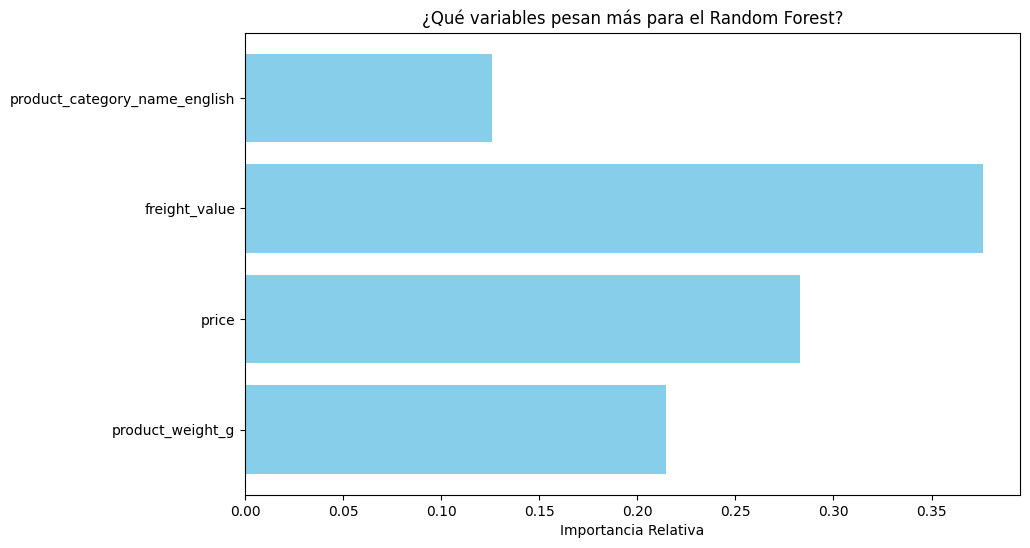

In [9]:
import matplotlib.pyplot as plt

# Extraer la importancia de las variables
importances = model.feature_importances_
feature_names = features

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Importancia Relativa')
plt.title('¿Qué variables pesan más para el Random Forest?')
plt.show()

**Conclusión:** "La importancia de variables confirma que el costo del flete y el peso del producto son los principales predictores del tiempo de entrega dentro de este modelo. Esto valida la hipótesis de la Fase 1: las dimensiones físicas imponen restricciones logísticas que impactan directamente en la promesa de servicio al cliente.

🎯 Recomendaciones Prescriptivas (Business Impact)

**Ajuste Dinámico de SLA:** Basado en el MAE de 5.11 días, se sugiere calibrar las promesas de entrega según el peso del producto para reducir la tasa de reclamos.

**Optimización de Inventario Geográfico:** Dado que las variables intrínsecas explican el 19% de la varianza, el **81%** restante (geográfico) sugiere que Olist debe incentivar el almacenamiento de productos pesados en centros de distribución cercanos a las zonas de mayor demanda.

**Mitigación Proactiva:** Implementar el modelo como un motor de reglas que identifique órdenes "fuera de norma" para priorizar su despacho en la cola logística.